# Week 1, Matchup Predictions

First real predictions of the season, comparing my roster against my
opponent's, position by position, across two leagues with different
scoring rules. Made entirely from last season's data via the
shrinkage-blended estimate from the base model, since no current-season
games exist yet at the time this was written.

Each comparison shows an actual probability, not just who's projected
to score more, and the same players are scored under each league's own
rules, so the same matchup can look different depending on what a
league actually rewards.

See `00_building_the_model.ipynb` for the full statistical model behind
these numbers, and `METHODOLOGY.md` for the reasoning and testing
behind each piece.

In [10]:
#Getting the helper functions needed, developed in 00_building_the_model.ipynb
!rm -f data_pull.py data_pull.py.* scoring.py scoring.py.* stats.py stats.py.* matchup.py matchup.py.*
!wget -q -O data_pull.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/data_pull.py
!wget -q -O scoring.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/scoring.py
!wget -q -O stats.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/stats.py
!wget -q -O matchup.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/matchup.py

from data_pull import get_player_id, get_game_log #type: ignore
from scoring import SKATER_FIELD_MAP, GOALIE_FIELD_MAP, apply_scoring, apply_scoring_breakdown #type: ignore
from stats import get_player_estimates, clean_goalie_log, build_full_skater_log #type: ignore
from matchup import compare_players, print_comparison #type: ignore

import pandas as pd
import matplotlib.pyplot as plt
import time
import requests

from scipy.stats import norm
import numpy as np

LAST_SEASON = "20252026"
PRIOR_SEASON = "20242025"

## League scoring configs and matchups

Each league's actual scoring rules, used to score the same players
under each league's own weights. The matchups provided are for the players in the corresponding position slot for me, and my opponent for the first week. This does not include the players on the bench for either team.

In [2]:
league_scoring = {
    "league_1": {
        "skater": {"G": 2, "A": 1, "PIM": -0.25, "PPG": 0.5, "SHG": 2, "SHA": 1, "GWG": 1, "SOG": 0.1, "HIT": 0.25, "BLK": 0.25},
        "goalie": {"W": 5, "GA": -1, "SV": 0.1, "SHO": 5},
    },
    "league_2": {
        "skater": {"G": 2.5, "A": 1.5, "PIM": -0.25, "PPG": 0.5, "PPA": 0.25,"SHG": 1, "SHA": 0.5,"GWG": 1, "SOG": 0.1, "HIT": 0.4, "BLK": 0.5},
        "goalie": {"W": 5, "GA": -1, "SV": 0.15, "SHO": 5},
    },
    "league_3": {
        "skater": {"G": 2.55, "A": 2.37, "PPP": 1.77, "SHP": 1.73,"GWG": 3.0, "SOG": 0.1, "HIT": 0.2, "BLK": 0.15},
        "goalie": {"W": 3.85, "GA": -0.05, "SV": 0.03, "SHO": 5.75},
    },
}

In [ ]:
matchups = {
    # league_1 excluded, draft hasn't happened yet, hoping to update before the season starts

    # "league_2": [
    #     {"position": "C", "me": "Nathan MacKinnon", "opponent": "Macklin Celebrini"},
    #     {"position": "C", "me": "Sebastian Aho", "opponent": "Brady Tkachuk"},
    #     {"position": "LW", "me": "Filip Forsberg", "opponent": "Dylan Guenther"},
    #     {"position": "LW", "me": "Tim Stutzle", "opponent": "Will Smith"},
    #     {"position": "RW", "me": "Matt Boldy", "opponent": "Martin Necas"},
    #     {"position": "RW", "me": "Drake Batherson", "opponent": "Adrian Kempe"},
    #     {"position": "D", "me": "Jakob Chychrun", "opponent": "Erik Karlsson"},
    #     {"position": "D", "me": "Jackson LaCombe", "opponent": "Filip Hronek"},
    #     {"position": "D", "me": "Mattias Samuelsson", "opponent": "Mike Matheson"},
    #     # Charlie McAvoy is suspended for the season's first 6 games,
    #     # and my opponent only carries 3 defensemen this week anyway,
    #     # so this slot has no real comparison to make
    #     {"position": "D", "me": "Charlie McAvoy (suspended, first 6 games)", "opponent": "None (opponent short a D)"},
    #     {"position": "UTIL", "me": "Nico Hischier", "opponent": "Adam Fantilli"},
    #     {"position": "UTIL", "me": "Juraj Slafkovsky", "opponent": "Ivan Demidov"},
    #     {"position": "G", "me": "Jake Oettinger", "opponent": "Ilya Sorokin"},
    #     {"position": "G", "me": "Mackenzie Blackwood", "opponent": "Carter Hart"},
    # ],

    "league_3": [
        {"position": "C", "me": "Connor McDavid", "opponent": "Brady Tkachuk"},
        {"position": "C", "me": "Auston Matthews", "opponent": "Mark Scheifele"},
        {"position": "C", "me": "Tim Stutzle", "opponent": "Adam Fantilli"},
        {"position": "LW", "me": "Kyle Connor", "opponent": "Kirill Kaprizov"},
        {"position": "LW", "me": "Clayton Keller", "opponent": "Brandon Hagel"},
        {"position": "LW", "me": "J.T. Miller", "opponent": "Timo Meier"},
        {"position": "RW", "me": "Martin Necas", "opponent": "Kirill Marchenko"},
        {"position": "RW", "me": "Sam Reinhart", "opponent": "Alexis Lafreniere"},
        {"position": "RW", "me": "Porter Martone", "opponent": "Logan Stankoven"},
        {"position": "F", "me": "Alex Ovechkin", "opponent": "Gavin McKenna"},
        {"position": "F", "me": "Tom Wilson", "opponent": "Sam Bennett"},
        {"position": "D", "me": "Jakob Chychrun", "opponent": "Cale Makar"},
        {"position": "D", "me": "Mikhail Sergachev", "opponent": "Lane Hutson"},
        {"position": "D", "me": "Thomas Harley", "opponent": "Jake Sanderson"},
        {"position": "D", "me": "Rasmus Andersson", "opponent": "Brandt Clarke"},
        {"position": "UTIL", "me": "Brock Nelson", "opponent": "Nikolaj Ehlers"},
        {"position": "G", "me": "Karel Vejmelka", "opponent": "Igor Shesterkin"},
        {"position": "G", "me": "Jakub Dobes", "opponent": "Jacob Markstrom"},
    ],
}

In [ ]:
def run_position_comparisons(league_name):
    scoring = league_scoring[league_name]
    results = []

    for matchup in matchups[league_name]:
        position = matchup["position"]

        if isinstance(matchup["opponent"], str) and matchup["opponent"].startswith("None"):
            results.append({"position": position, "me": matchup["me"], "opponent": matchup["opponent"],
                             "probability": None, "note": "no opponent this slot"})
            continue

        cfg = scoring["goalie"] if position == "G" else scoring["skater"]
        fmap = GOALIE_FIELD_MAP if position == "G" else SKATER_FIELD_MAP

        me_id = matchup["me"] if isinstance(matchup["me"], int) else get_player_id(matchup["me"])
        opp_id = matchup["opponent"] if isinstance(matchup["opponent"], int) else get_player_id(matchup["opponent"])

        me_est = get_player_estimates(me_id, position, cfg, fmap, season=LAST_SEASON, prior_season=PRIOR_SEASON)
        opp_est = get_player_estimates(opp_id, position, cfg, fmap, season=LAST_SEASON, prior_season=PRIOR_SEASON)

        if me_est is None or opp_est is None:
            reason_me = "no data" if me_est is None else "ok"
            reason_opp = "no data" if opp_est is None else "ok"
            results.append({"position": position, "me": matchup["me"], "opponent": matchup["opponent"],
                             "probability": None, "note": f"skipped ({matchup['me']}: {reason_me}, {matchup['opponent']}: {reason_opp})"})
            continue

        result = compare_players(me_est, opp_est, matchup["me"], matchup["opponent"])
        results.append({"position": position, "me": matchup["me"], "opponent": matchup["opponent"],
                         "probability": result["probability_a_outperforms_b"], "note": ""})

    return pd.DataFrame(results)

league_results = {league: run_position_comparisons(league) for league in matchups}

Matched 'Connor McDavid' to 'Connor McDavid'
Matched 'Brady Tkachuk' to 'Brady Tkachuk'
Pulling fresh game log for 8478402, 20252026
Pulling fresh game log for 8478402, 20242025
Loading game log for 8480801, 20252026 from cache, 0.1 hours old
Loading game log for 8480801, 20242025 from cache, 0.1 hours old
Matched 'Auston Matthews' to 'Auston Matthews'
Matched 'Mark Scheifele' to 'Mark Scheifele'
Pulling fresh game log for 8479318, 20252026
Pulling fresh game log for 8479318, 20242025
Pulling fresh game log for 8476460, 20252026
Pulling fresh game log for 8476460, 20242025
Matched 'Tim Stutzle' to 'Tim Stützle'
Matched 'Adam Fantilli' to 'Adam Fantilli'
Loading game log for 8482116, 20252026 from cache, 0.1 hours old
Pulling fresh game log for 8482116, 20242025
Pulling fresh game log for 8484166, 20252026
Pulling fresh game log for 8484166, 20242025
Matched 'Kyle Connor' to 'Kyle Connor'
Matched 'Kirill Kaprizov' to 'Kirill Kaprizov'
Pulling fresh game log for 8478398, 20252026
Pulling

## Summary, position-by-position advantage

In [ ]:
for league, df in league_results.items():
    print(f"\n=== {league.upper()} ===")
    display_df = df.copy()
    display_df["edge"] = display_df["probability"].apply(
        lambda p: "advantage me" if p is not None and p > 0.5 else ("advantage opponent" if p is not None and p < 0.5 else "n/a")
    )
    display_df["probability"] = display_df["probability"].apply(lambda p: f"{p:.1%}" if p is not None else "n/a")
    print(display_df.to_string(index=False))


=== LEAGUE_2 ===
position                                        me                  opponent probability                  note               edge
       C                          Nathan MacKinnon         Macklin Celebrini       55.4%                             advantage me
       C                             Sebastian Aho             Brady Tkachuk       41.4%                       advantage opponent
      LW                            Filip Forsberg            Dylan Guenther       52.9%                             advantage me
      LW                               Tim Stutzle                Will Smith       64.1%                             advantage me
      RW                                Matt Boldy              Martin Necas       50.2%                             advantage me
      RW                           Drake Batherson              Adrian Kempe       48.8%                       advantage opponent
       D                            Jakob Chychrun             Erik Karl

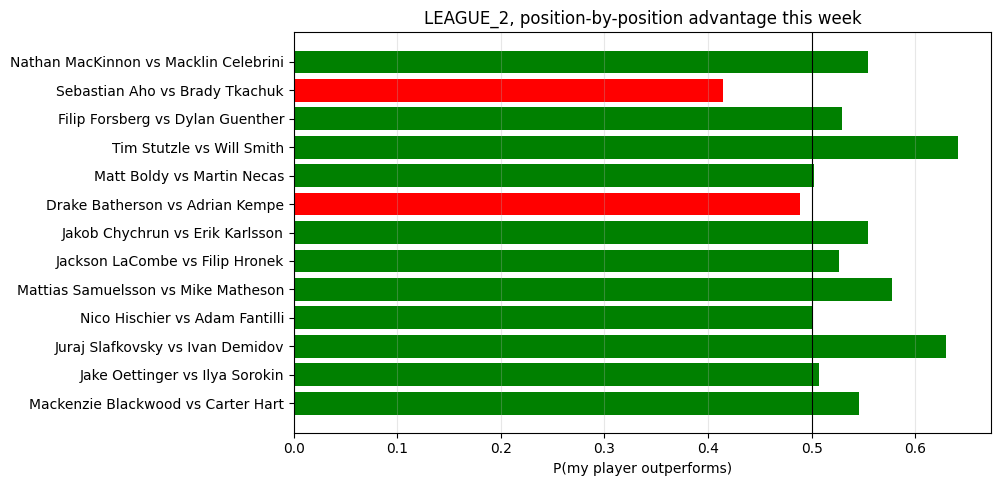

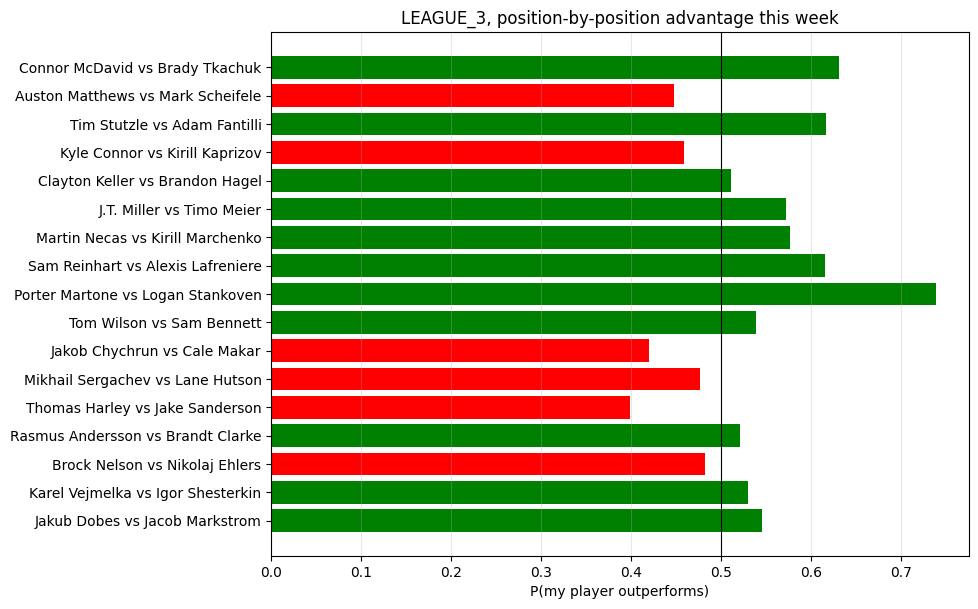

In [ ]:
for league, df in league_results.items():
    plot_df = df.dropna(subset=["probability"])
    labels = [f"{row['me']} vs {row['opponent']}" for _, row in plot_df.iterrows()]
    probs = plot_df["probability"].tolist()
    colors = ["green" if p > 0.5 else "red" for p in probs]

    plt.figure(figsize=(9, max(4, len(labels) * 0.4)))
    plt.barh(labels, probs, color=colors)
    plt.axvline(0.5, color="black", linewidth=0.8)
    plt.xlabel("P(my player outperforms)")
    plt.title(f"{league.upper()}, position-by-position advantage this week")
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis="x")
    plt.show()

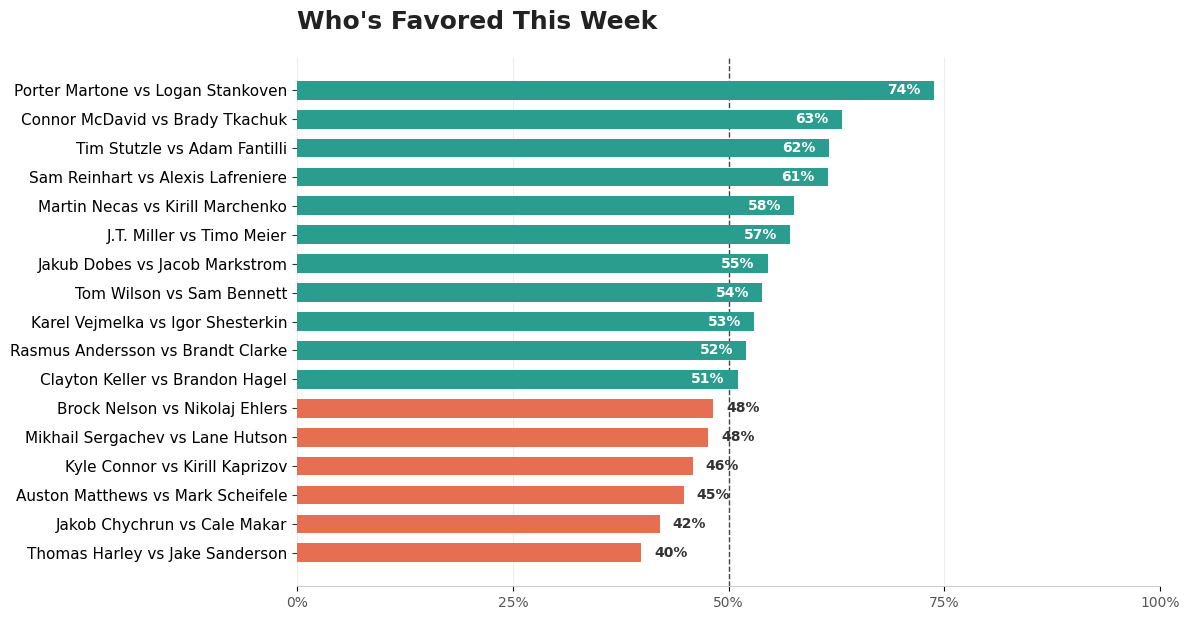

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# pull league_3's data, sorted by probability for a cleaner visual story
plot_df = league_results["league_3"].dropna(subset=["probability"]).copy()
plot_df = plot_df.sort_values("probability", ascending=True).reset_index(drop=True)

labels = [f"{row['me']} vs {row['opponent']}" for _, row in plot_df.iterrows()]
probs = plot_df["probability"].tolist()

# modern, muted palette instead of pure red/green
color_favored = "#2A9D8F"     # teal
color_unfavored = "#E76F51"   # coral
colors = [color_favored if p > 0.5 else color_unfavored for p in probs]

fig, ax = plt.subplots(figsize=(12, 6.3), dpi=100)  # 1200x630 at dpi=100

bars = ax.barh(labels, probs, color=colors, height=0.65, zorder=3)

# reference line at 50%
ax.axvline(0.5, color="#444444", linewidth=1, linestyle="--", zorder=2)

# value labels on each bar
for bar, prob in zip(bars, probs):
    x_pos = bar.get_width() + 0.01 if prob < 0.5 else bar.get_width() - 0.01
    ha = "left" if prob < 0.5 else "right"
    text_color = "white" if prob >= 0.5 else "#333333"
    label_x = bar.get_width() - 0.015 if prob >= 0.5 else bar.get_width() + 0.015
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f"{prob:.0%}",
            va="center", ha="right" if prob >= 0.5 else "left",
            fontsize=10, fontweight="bold",
            color="white" if prob >= 0.5 else "#333333")

# clean up spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=10, color="#555555")
ax.tick_params(axis="y", labelsize=11, color="#333333")
ax.grid(axis="x", color="#eeeeee", zorder=0)

ax.set_title("Who's Favored This Week", fontsize=18, fontweight="bold", pad=20, loc="left", color="#222222")
# ax.text(0, 1.06, "Fantasy hockey matchup probabilities, League 3", transform=ax.transAxes,
#         fontsize=12, color="#777777")

plt.tight_layout()
plt.savefig("thumbnail_league3.png", dpi=100, bbox_inches="tight", facecolor="white")
plt.show()

Matched 'Nathan MacKinnon' to 'Nathan MacKinnon'
Loading game log for 8477492, 20252026 from cache, 3.3 hours old
Loading game log for 8477492, 20242025 from cache, 0.8 hours old
Matched 'Macklin Celebrini' to 'Macklin Celebrini'
Loading game log for 8484801, 20252026 from cache, 0.8 hours old
Loading game log for 8484801, 20242025 from cache, 0.8 hours old
Matched 'Sebastian Aho' to 'Sebastian Aho'
Loading game log for 8478427, 20252026 from cache, 2.4 hours old
Loading game log for 8478427, 20242025 from cache, 2.4 hours old
Matched 'Brady Tkachuk' to 'Brady Tkachuk'
Loading game log for 8480801, 20252026 from cache, 0.8 hours old
Loading game log for 8480801, 20242025 from cache, 0.8 hours old
Matched 'Filip Forsberg' to 'Filip Forsberg'
Loading game log for 8476887, 20252026 from cache, 0.8 hours old
Loading game log for 8476887, 20242025 from cache, 0.8 hours old
Matched 'Dylan Guenther' to 'Dylan Guenther'
Loading game log for 8482699, 20252026 from cache, 0.8 hours old
Loading g

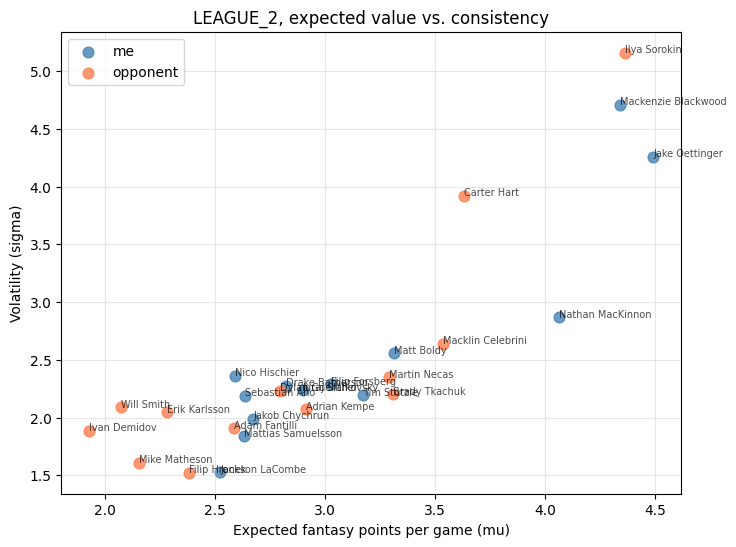

Matched 'Connor McDavid' to 'Connor McDavid'
Loading game log for 8478402, 20252026 from cache, 0.7 hours old
Loading game log for 8478402, 20242025 from cache, 0.7 hours old
Matched 'Brady Tkachuk' to 'Brady Tkachuk'
Loading game log for 8480801, 20252026 from cache, 1.0 hours old
Loading game log for 8480801, 20242025 from cache, 1.0 hours old
Matched 'Auston Matthews' to 'Auston Matthews'
Loading game log for 8479318, 20252026 from cache, 0.7 hours old
Loading game log for 8479318, 20242025 from cache, 0.7 hours old
Matched 'Mark Scheifele' to 'Mark Scheifele'
Loading game log for 8476460, 20252026 from cache, 0.7 hours old
Loading game log for 8476460, 20242025 from cache, 0.7 hours old
Matched 'Tim Stutzle' to 'Tim Stützle'
Loading game log for 8482116, 20252026 from cache, 1.0 hours old
Loading game log for 8482116, 20242025 from cache, 1.0 hours old
Matched 'Adam Fantilli' to 'Adam Fantilli'
Loading game log for 8484166, 20252026 from cache, 0.8 hours old
Loading game log for 84

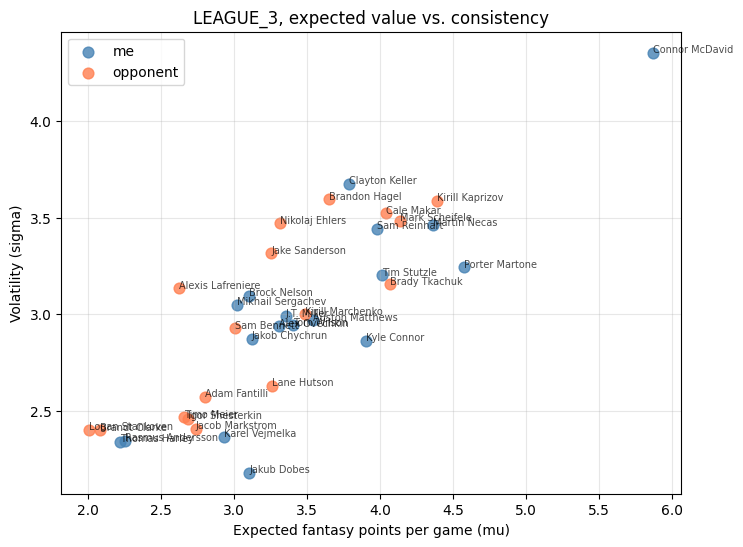

In [ ]:
def collect_estimates_for_plot(league_name):
    scoring = league_scoring[league_name]
    rows = []
    for matchup in matchups[league_name]:
        position = matchup["position"]
        if isinstance(matchup["opponent"], str) and matchup["opponent"].startswith("None"):
            continue
        cfg = scoring["goalie"] if position == "G" else scoring["skater"]
        fmap = GOALIE_FIELD_MAP if position == "G" else SKATER_FIELD_MAP
        for role, name in [("me", matchup["me"]), ("opponent", matchup["opponent"])]:
            pid = name if isinstance(name, int) else get_player_id(name)
            est = get_player_estimates(pid, position, cfg, fmap, season=LAST_SEASON, prior_season=PRIOR_SEASON)
            if est:
                rows.append({"name": name, "role": role, "mu": est["season_mu"], "sigma": est["season_sigma"]})
    return pd.DataFrame(rows)

for league in matchups:
    plot_df = collect_estimates_for_plot(league)
    plt.figure(figsize=(8, 6))
    for role, color in [("me", "steelblue"), ("opponent", "coral")]:
        subset = plot_df[plot_df["role"] == role]
        plt.scatter(subset["mu"], subset["sigma"], label=role, color=color, s=60, alpha=0.8)
        for _, row in subset.iterrows():
            plt.annotate(row["name"], (row["mu"], row["sigma"]), fontsize=7, alpha=0.7)
    plt.xlabel("Expected fantasy points per game (mu)")
    plt.ylabel("Volatility (sigma)")
    plt.title(f"{league.upper()}, expected value vs. consistency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
for league, df in league_results.items():
    valid = df.dropna(subset=["probability"])
    overall = valid["probability"].mean()
    favored_count = (valid["probability"] > 0.5).sum()
    print(f"{league.upper()}: favored in {favored_count}/{len(valid)} comparable slots, "
          f"average edge {overall:.1%}")

LEAGUE_2: favored in 11/13 comparable slots, average edge 53.6%
LEAGUE_3: favored in 11/17 comparable slots, average edge 53.4%


In [12]:
def plot_matchup_distributions(est_a, est_b, label_a, label_b):
    x = np.linspace(min(est_a["season_mu"], est_b["season_mu"]) - 3 * max(est_a["season_sigma"], est_b["season_sigma"]),
                     max(est_a["season_mu"], est_b["season_mu"]) + 3 * max(est_a["season_sigma"], est_b["season_sigma"]), 200)
    plt.figure(figsize=(8, 5))
    plt.plot(x, norm.pdf(x, est_a["season_mu"], est_a["season_sigma"]), label=label_a, color="steelblue")
    plt.fill_between(x, norm.pdf(x, est_a["season_mu"], est_a["season_sigma"]), alpha=0.3, color="steelblue")
    plt.plot(x, norm.pdf(x, est_b["season_mu"], est_b["season_sigma"]), label=label_b, color="coral")
    plt.fill_between(x, norm.pdf(x, est_b["season_mu"], est_b["season_sigma"]), alpha=0.3, color="coral")
    plt.xlabel("Fantasy points, one game")
    plt.ylabel("Probability density")
    plt.title(f"{label_a} vs. {label_b}, modeled distributions")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Matched 'Porter Martone' to 'Porter Martone'
Matched 'Logan Stankoven' to 'Logan Stankoven'
Loading game log for 8485406, 20252026 from cache, 0.1 hours old
Pulling fresh game log for 8485406, 20242025
No games found for 8485406 in 20242025, player likely wasn't in the NHL that season
Pulling fresh game log for 8482702, 20252026
Pulling fresh game log for 8482702, 20242025


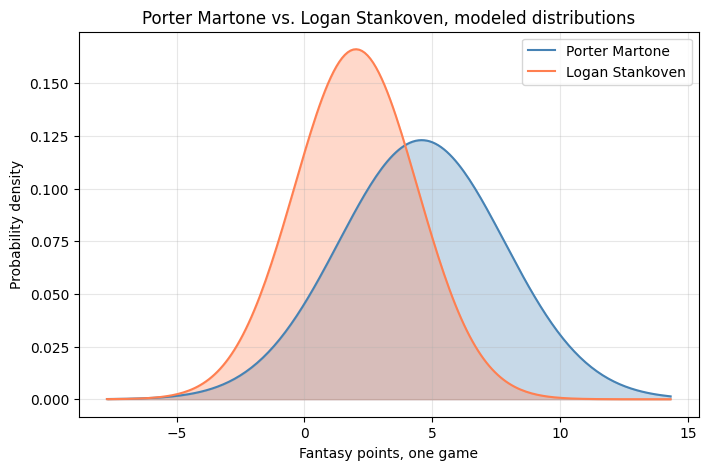

In [13]:
# example, the most lopsided call, Martone vs Stankoven
martone_id = get_player_id("Porter Martone")
stankoven_id = get_player_id("Logan Stankoven")
martone_est = get_player_estimates(martone_id, "RW", league_scoring["league_3"]["skater"], SKATER_FIELD_MAP,
                                     season=LAST_SEASON, prior_season=PRIOR_SEASON)
stankoven_est = get_player_estimates(stankoven_id, "RW", league_scoring["league_3"]["skater"], SKATER_FIELD_MAP,
                                       season=LAST_SEASON, prior_season=PRIOR_SEASON)
plot_matchup_distributions(martone_est, stankoven_est, "Porter Martone", "Logan Stankoven")

## My picks this week

1. **Tim Stutzle over Will Smith** (league 2, LW), 64.1% confidence.
   Full season of data on both sides, a real, trustworthy gap in
   expected production.
2. **Connor McDavid over Brady Tkachuk** (league 3, C), 63.1%
   confidence. The most trustworthy high-confidence call this week,
   built on complete data for both players, not a thin sample.
3. **Porter Martone over Logan Stankoven** (league 3, RW), 73.8%
   confidence, the highest raw number this week, but treat with real
   caution, Martone has only 9 games of prior-season data (10 points),
   so this leans on a genuinely thin, noisy prior rather than an
   established one.

Now, do I think I will win both leauges this week, probably not, however, I do believe I have a favourable lineup in leauge 3, that will hopefully lead to the W.

## This week's calls (full breakdown)

Slightly favored in both active leagues this week, league 1 hasn't
drafted yet. League 2, favored in 11 of 13 comparable slots, 53.6%
average edge. League 3, favored in 11 of 17, 53.4% average edge.

Closest calls, genuine coin flips: Matt Boldy vs. Martin Necas (50.2%)
and Nico Hischier vs. Adam Fantilli (50.1%) in league 2, Brock Nelson
vs. Nikolaj Ehlers (48.2%) in league 3.

Same player, opposite verdict: Jakob Chychrun is favored against Erik
Karlsson in league 2 (55.4%) but not against Cale Makar in league 3
(42.0%), same player, same week, purely a function of who he's
actually facing.

Skipped: Charlie McAvoy (suspended for the season's first 6 games) had
no opponent to compare against. Alex Ovechkin vs. Gavin McKenna was
skipped, McKenna has no 2025-26 NHL games yet.

Two real bugs caught while building this: a typo (Jacob vs. Jakob
Chychrun) that the model correctly flagged as a low-confidence match
rather than silently guessing wrong, and a name-resolution mismatch for
Carter Hart caused by his unusual season (a leave of absence, then a
move to Vegas), fixed by adding a fallback search. Both fixed in
src/data_pull.py, not hidden.

## Sleeper picks

The league-wide scan for trending players (looping over every skater
to flag anyone rising relative to their own baseline) is too slow to
run reliably for a weekly notebook as currently built, a full pass
takes long enough that it isn't practical to include for week 1.

For this week, sleeper picks are 3 candidates I identified manually,
evaluated the same way (recent form vs. season baseline), rather than
surfaced by the scan. The scan itself worked correctly when tested,
see the base notebook, it's a speed problem, not a correctness one,
worth revisiting once there's a faster way to run it, likely by
narrowing the pool upfront (by position, or by team) rather than
scanning the entire league every time.

Specifically, my three picks are Gabe Perreault, Chris Kreider, and Bobby McMann. My thoughts behind it are, as of 09/17/26, all three players are under 17% rostered on Yahoo. However, all three may benefit from the possibility of strong line assignments.

Specifically, for Gabe Perreault, a first line assignment with Zibanejad and Lafrenière could indicate an influx of fantasy points. The same idea for Chris Kreider and Bobby McMann, both on new (or relatively new teams), being on either of the top two lines could indicate higher production on two of the younger teams in the leauge.  

Worth being clear about what this does and doesn't show for Perreault
and Kreider specifically. The actual idea for both is a potential
future linemate change (Perreault possibly moving up next to Miller or
Dorofeyev, Kreider reportedly skating with Montreal's top line in
practice), and that hasn't happened in games yet, only practice
reports. The model has no way to project the effect of a lineup change
before it occurs, it can only show current recent-vs-season trend.
Worth tracking both going forward, if the linemate change actually
happens, it should show up as a rising recent_mu in a future week's
notebook, that's the actual test of the thesis, not this week's chart.

We also did not consider sleeper goalies as it is a little too early in the season, and ths starters are likely the starters. However, if I were to look, I would likely look at Sergei Murashov (only 30% rostered) and Devon Levi (only 5% rostered), as potential candidates.

In [ ]:
sleeper_candidates = [
    {"name": "Gabe Perreault", "position": "RW", "leagues": ["league_2", "league_3"]},
    {"name": "Chris Kreider", "position": "LW", "leagues": ["league_2", "league_3"]},
    {"name": "Bobby McMann", "position": "LW", "leagues": ["league_2", "league_3"]},
]


In [ ]:
def evaluate_sleepers(candidates):
    rows = []
    for candidate in candidates:
        position = candidate["position"]
        for league in candidate["leagues"]:
            scoring = league_scoring[league]
            cfg = scoring["goalie"] if position == "G" else scoring["skater"]
            fmap = GOALIE_FIELD_MAP if position == "G" else SKATER_FIELD_MAP

            pid = get_player_id(candidate["name"])
            est = get_player_estimates(pid, position, cfg, fmap, season=LAST_SEASON, prior_season=PRIOR_SEASON)

            if est is None:
                rows.append({"name": candidate["name"], "league": league, "position": position,
                             "season_mu": None, "recent_mu": None, "trend": "no data"})
                continue

            trend_pct = (est["recent_mu"] - est["season_mu"]) / abs(est["season_mu"]) if est["season_mu"] != 0 else 0
            trend = "up" if trend_pct > 0.1 else ("down" if trend_pct < -0.1 else "flat")

            rows.append({"name": candidate["name"], "league": league, "position": position,
                         "season_mu": est["season_mu"], "recent_mu": est["recent_mu"],
                         "trend_pct": trend_pct, "trend": trend})

    return pd.DataFrame(rows)

sleeper_results = evaluate_sleepers(sleeper_candidates)
print(sleeper_results.to_string(index=False))

Matched 'Gabe Perreault' to 'Gabe Perreault'
Loading game log for 8484210, 20252026 from cache, 2.7 hours old
Loading game log for 8484210, 20242025 from cache, 2.7 hours old
Matched 'Gabe Perreault' to 'Gabe Perreault'
Loading game log for 8484210, 20252026 from cache, 2.7 hours old
Loading game log for 8484210, 20242025 from cache, 2.7 hours old
Matched 'Chris Kreider' to 'Chris Kreider'
Loading game log for 8475184, 20252026 from cache, 2.7 hours old
Loading game log for 8475184, 20242025 from cache, 2.7 hours old
Matched 'Chris Kreider' to 'Chris Kreider'
Loading game log for 8475184, 20252026 from cache, 2.7 hours old
Loading game log for 8475184, 20242025 from cache, 2.7 hours old
Matched 'Bobby McMann' to 'Bobby McMann'
Loading game log for 8482259, 20252026 from cache, 2.7 hours old
Loading game log for 8482259, 20242025 from cache, 2.7 hours old
Matched 'Bobby McMann' to 'Bobby McMann'
Loading game log for 8482259, 20252026 from cache, 2.7 hours old
Loading game log for 848225

Matched 'Gabe Perreault' to 'Gabe Perreault'
Loading game log for 8484210, 20252026 from cache, 2.8 hours old
Loading game log for 8484210, 20242025 from cache, 2.8 hours old
Matched 'Gabe Perreault' to 'Gabe Perreault'
Loading game log for 8484210, 20252026 from cache, 2.8 hours old
Loading game log for 8484210, 20242025 from cache, 2.8 hours old
Matched 'Chris Kreider' to 'Chris Kreider'
Loading game log for 8475184, 20252026 from cache, 2.8 hours old
Loading game log for 8475184, 20242025 from cache, 2.8 hours old
Matched 'Chris Kreider' to 'Chris Kreider'
Loading game log for 8475184, 20252026 from cache, 2.8 hours old
Loading game log for 8475184, 20242025 from cache, 2.8 hours old
Matched 'Bobby McMann' to 'Bobby McMann'
Loading game log for 8482259, 20252026 from cache, 2.8 hours old
Loading game log for 8482259, 20242025 from cache, 2.8 hours old
Matched 'Bobby McMann' to 'Bobby McMann'
Loading game log for 8482259, 20252026 from cache, 2.8 hours old
Loading game log for 848225

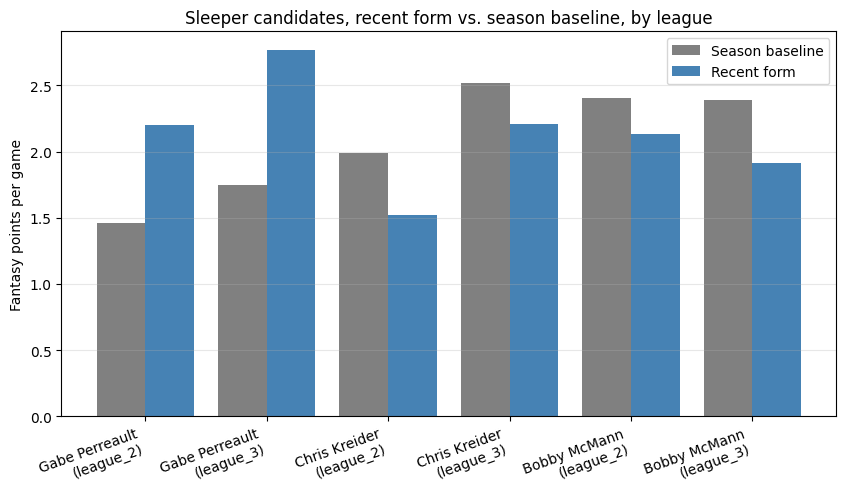

In [ ]:
sleeper_results = evaluate_sleepers(sleeper_candidates)
print(sleeper_results.to_string(index=False))

plot_df = sleeper_results.dropna(subset=["season_mu"])
labels = [f"{row['name']}\n({row['league']})" for _, row in plot_df.iterrows()]
x = range(len(plot_df))

plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], plot_df["season_mu"], width=0.4, label="Season baseline", color="gray")
plt.bar([i + 0.2 for i in x], plot_df["recent_mu"], width=0.4, label="Recent form", color="steelblue")
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("Fantasy points per game")
plt.title("Sleeper candidates, recent form vs. season baseline, by league")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.show()

Matched 'Bobby McMann' to 'Bobby McMann'
Loading game log for 8482259, 20252026 from cache, 2.8 hours old


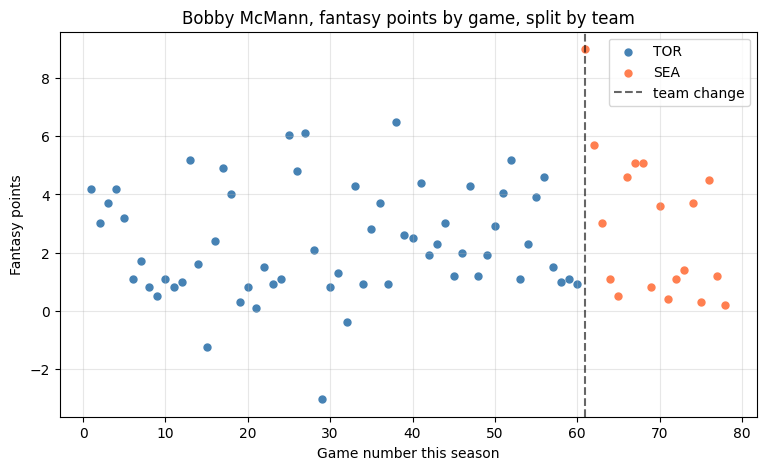

TOR: 2.33 fantasy points per game average
SEA: 2.85 fantasy points per game average
Matched 'Bobby McMann' to 'Bobby McMann'
Loading game log for 8482259, 20252026 from cache, 2.8 hours old


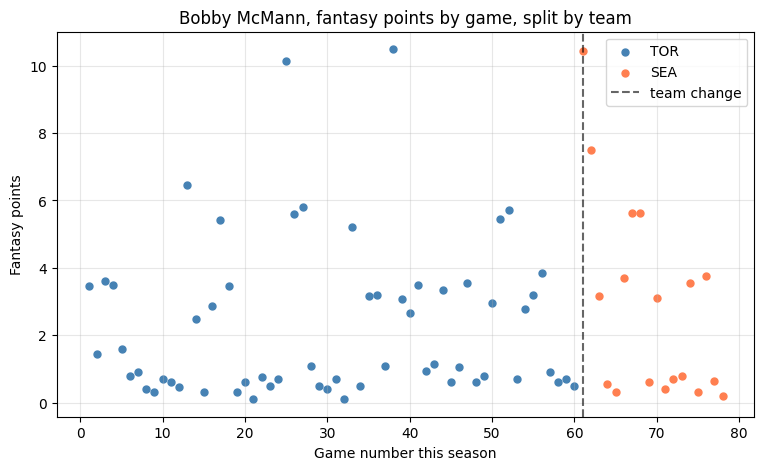

TOR: 2.30 fantasy points per game average
SEA: 2.83 fantasy points per game average


In [ ]:
def plot_team_change(name_query, scoring_config, field_map, season=LAST_SEASON):
    pid = get_player_id(name_query)
    log = build_full_skater_log(pid, season)

    if log.empty:
        print(f"No data for {name_query}")
        return

    log["fantasy_points"] = apply_scoring(log, scoring_config, field_map)
    log["game_number"] = range(1, len(log) + 1)
    teams = log["teamAbbrev"].unique()

    plt.figure(figsize=(9, 5))
    colors = {team: color for team, color in zip(teams, ["steelblue", "coral", "seagreen"])}
    for team in teams:
        team_games = log[log["teamAbbrev"] == team]
        plt.scatter(team_games["game_number"], team_games["fantasy_points"], label=team, color=colors[team], s=25)

    if len(teams) > 1:
        transition_game = log[log["teamAbbrev"] != log["teamAbbrev"].iloc[0]]["game_number"].min()
        plt.axvline(transition_game, color="black", linestyle="--", alpha=0.6, label="team change")

    plt.xlabel("Game number last season")
    plt.ylabel("Fantasy points")
    plt.title(f"{name_query}, fantasy points by game, split by team")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    for team in teams:
        team_avg = log[log["teamAbbrev"] == team]["fantasy_points"].mean()
        print(f"{team}: {team_avg:.2f} fantasy points per game average")

plot_team_change("Bobby McMann", league_scoring["league_2"]["skater"], SKATER_FIELD_MAP)
plot_team_change("Bobby McMann", league_scoring["league_3"]["skater"], SKATER_FIELD_MAP)

## Sleeper picks summary

Three candidates, all forwards, evaluated under both active leagues'
scoring rules to check whether each story holds up regardless of how
a league weights categories.

**Gabe Perreault** is the strongest case, he finished last season
trending up, 51% above his own full-season average in the final
stretch under league 2 scoring, 59% under league 3, consistent across
both systems. Since this season hasn't started, this reflects how he
was playing at the end of last season, not anything happening right
now. Worth watching closely once real games begin, if that late-season
form carries over, especially if it coincides with a line change, that's a real, early confirmation of
the hypothesis, not a coincidence.

**Bobby McMann** is a genuinely different situation from the other two,
not speculative, an already-completed trade from Toronto to Seattle.
His average production jumped from 2.30-2.33 fantasy points per game
with Toronto to 2.83-2.85 with Seattle, consistent under both leagues'
scoring, an increase of roughly half a point per game. Worth noting his
overall recent_mu still reads as "trending down" in the table above,
that's because the trend calculation compares against his full-season
average, which blends both teams together, the team-specific comparison
is the more meaningful number here, not the blended trend.

**Chris Kreider** is currently trending down under both scoring
systems (-23% and -12%), the weakest of the three right now. His case
remains fully speculative, tied to a reported move onto Montreal's top
line in practice, which hasn't yet shown up in game results. Worth
revisiting once (or if) that lineup change actually happens.

## Scanning for sleeper candidates, for week 2's predictions

Rostered % isn't available from this data source (it's a Yahoo-
specific stat, not something the NHL API exposes), so this can't
directly find "low-rostered" players. Instead, this scans all skaters,
excludes clear stars by season-level production, and flags whoever's
recent form sits well above their own season baseline, real, trending
players worth checking against actual availability in each league. For this first week we will restrict to just forwards and defensemen, as at this point, the starters for each of the teams will likely be starting the majority of the games.

In [ ]:
NHL_TEAMS = [
    "ANA","BOS","BUF","CAR","CBJ","CGY","CHI","COL","DAL","DET",
    "EDM","FLA","LAK","MIN","MTL","NJD","NSH","NYI","NYR","OTT",
    "PHI","PIT","SEA","SJS","STL","TBL","TOR","UTA","VAN","VGK",
    "WPG","WSH"
]

def get_team_roster(team_abbr):
    url = f"https://api-web.nhle.com/v1/roster/{team_abbr}/current"
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()
    rows = []
    for group in ["forwards", "defensemen"]:  # goalies excluded from this scan for now
        for player in data.get(group, []):
            rows.append({
                "player_id": player["id"],
                "name": f"{player['firstName']['default']} {player['lastName']['default']}",
                "position": player["positionCode"],
                "team": team_abbr,
            })
    return pd.DataFrame(rows)

def scan_for_trending_players(scoring_config, field_map, max_season_mu=2.0, min_trend_pct=0.25, pause=0.5):
    """
    Scans every skater league-wide, excludes likely-rostered stars via
    a season_mu ceiling, flags anyone whose recent form is notably
    above their own season baseline. max_season_mu and min_trend_pct
    are judgment calls, tune based on what actually looks reasonable.
    """
    all_rosters = []
    for team in NHL_TEAMS:
        all_rosters.append(get_team_roster(team))
        time.sleep(pause)
    all_skaters = pd.concat(all_rosters, ignore_index=True)

    candidates = []
    for _, player in all_skaters.iterrows():
        est = get_player_estimates(player["player_id"], player["position"], scoring_config, field_map,
                                     season=LAST_SEASON, prior_season=PRIOR_SEASON)
        if est is None or est["season_mu"] > max_season_mu:
            continue
        trend_pct = (est["recent_mu"] - est["season_mu"]) / abs(est["season_mu"]) if est["season_mu"] != 0 else 0
        if trend_pct > min_trend_pct:
            candidates.append({"name": player["name"], "team": player["team"], "position": player["position"],
                                "season_mu": est["season_mu"], "recent_mu": est["recent_mu"], "trend_pct": trend_pct})

    return pd.DataFrame(candidates).sort_values("trend_pct", ascending=False)

# Not run this week, see the note above, this is prep for week 2 once
# there's a faster way to scope the scan (by position or team) rather
# than looping over every skater league-wide.
# trending = scan_for_trending_players(league_scoring["league_2"]["skater"], SKATER_FIELD_MAP)
# trending.head(15)

## Bonus: Should I trade Kyle Connor for Cole Caufield? (League 1)

League 1 drafted last night (Sept 25), so this is the first real
question from that league, a straight one-for-one trade evaluation
rather than a lineup comparison. Same caveat as everything else this
week, no 2026-27 games have been played yet, so this leans entirely
on last season's data via the shrinkage estimate, there's no current-
season trend to point to yet.

My thought is that Winnipeg is a wildcard, no one really seems to know
what is going on, whether they'll be sellers or not, etc. I still
believe Kyle Connor will produce offensively, as they're working with
a similar lineup to years prior, however, I am wondering if that
production may begin to taper this year.

On the other side, Cole Caufield had a career year last season. As a
result, his draft value increased, and in this league he was picked
12th overall, whereas Kyle Connor was picked 20th overall. I'd assume
some regression to be true, and I don't know if Caufield will hit the
50 goal mark again this season, but I do think the 40's range is
doable.

So I want to test it. My gut is to take the slight risk and make the
trade, but I was also curious to see what the model says. I'm guessing
that since it's based on the last two seasons, Caufield may be favoured
at this point, but I believe only slightly.

One thing worth being upfront about, the model can't actually test for
regression, it only knows what already happened. If Caufield's career
year was partly a career-high outlier, the model has no way to know
that, it just sees his most recent, heavily-weighted data point. So
this isn't really a test of "will Caufield regress," it's a test of
"given only what's already happened, who does the model favour," my
own regression expectation is a separate judgment call layered on top
of that.

In [3]:
connor_id = get_player_id("Kyle Connor")
caufield_id = get_player_id("Cole Caufield")

connor_est = get_player_estimates(connor_id, "LW", league_scoring["league_1"]["skater"], SKATER_FIELD_MAP,
                                    season=LAST_SEASON, prior_season=PRIOR_SEASON)
caufield_est = get_player_estimates(caufield_id, "RW", league_scoring["league_1"]["skater"], SKATER_FIELD_MAP,
                                      season=LAST_SEASON, prior_season=PRIOR_SEASON)

result = compare_players(connor_est, caufield_est, "Kyle Connor", "Cole Caufield")
print_comparison(result)

Matched 'Kyle Connor' to 'Kyle Connor'
Matched 'Cole Caufield' to 'Cole Caufield'
Pulling fresh game log for 8478398, 20252026
Pulling fresh game log for 8478398, 20242025
Pulling fresh game log for 8481540, 20252026
Pulling fresh game log for 8481540, 20242025
Kyle Connor: mu=2.22, sigma=1.73
Cole Caufield: mu=2.38, sigma=2.02
P(Kyle Connor outperforms Cole Caufield) = 47.6%


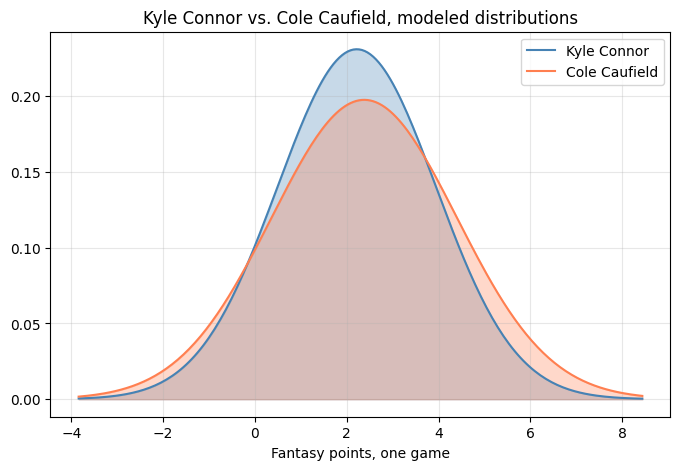

In [7]:
plot_matchup_distributions(connor_est, caufield_est, "Kyle Connor", "Cole Caufield")

In [11]:
connor_log = build_full_skater_log(connor_id, LAST_SEASON)
caufield_log = build_full_skater_log(caufield_id, LAST_SEASON)

connor_breakdown = apply_scoring_breakdown(connor_log, league_scoring["league_1"]["skater"], SKATER_FIELD_MAP)
caufield_breakdown = apply_scoring_breakdown(caufield_log, league_scoring["league_1"]["skater"], SKATER_FIELD_MAP)

comparison_table = pd.DataFrame({
    "Connor per game": connor_breakdown.mean(),
    "Caufield per game": caufield_breakdown.mean(),
})
comparison_table

Loading game log for 8478398, 20252026 from cache, 0.1 hours old
Loading game log for 8481540, 20252026 from cache, 0.1 hours old


,Connor per game,Caufield per game
G_pts,0.951220,1.259259
A_pts,0.646341,0.456790
PIM_pts,-0.048780,-0.043210
PPG_pts,0.030488,0.067901
SHG_pts,0.048780,0.000000
SHA_pts,0.012195,0.000000
GWG_pts,0.060976,0.148148
SOG_pts,0.334146,0.318519
HIT_pts,0.109756,0.154321
BLK_pts,0.057927,0.064815


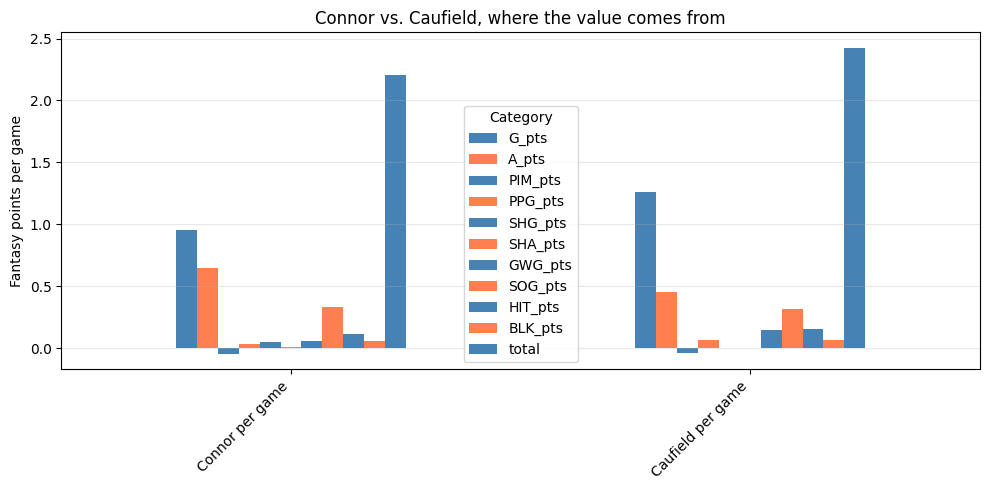

In [14]:
comparison_table.T.plot(kind="bar", figsize=(10, 5), color=["steelblue", "coral"])
plt.ylabel("Fantasy points per game")
plt.title("Connor vs. Caufield, where the value comes from")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Category")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

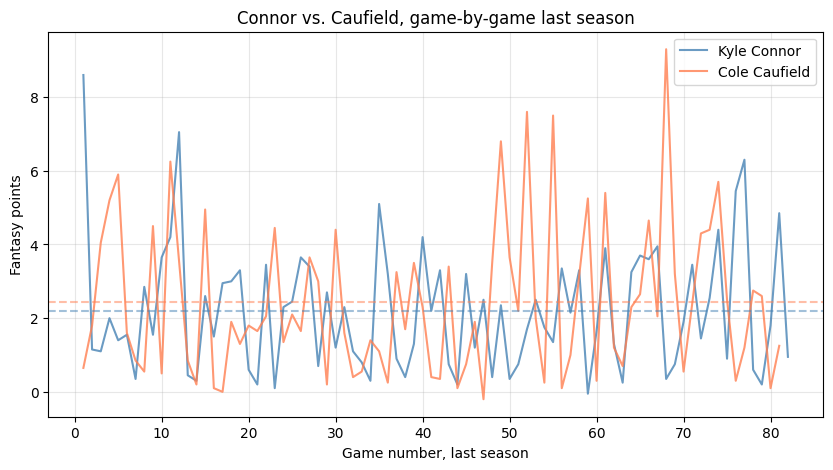

In [15]:
connor_log["fantasy_points"] = apply_scoring(connor_log, league_scoring["league_1"]["skater"], SKATER_FIELD_MAP)
caufield_log["fantasy_points"] = apply_scoring(caufield_log, league_scoring["league_1"]["skater"], SKATER_FIELD_MAP)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(connor_log)+1), connor_log["fantasy_points"], label="Kyle Connor", color="steelblue", alpha=0.8)
plt.plot(range(1, len(caufield_log)+1), caufield_log["fantasy_points"], label="Cole Caufield", color="coral", alpha=0.8)
plt.axhline(connor_log["fantasy_points"].mean(), color="steelblue", linestyle="--", alpha=0.5)
plt.axhline(caufield_log["fantasy_points"].mean(), color="coral", linestyle="--", alpha=0.5)
plt.xlabel("Game number, last season")
plt.ylabel("Fantasy points")
plt.title("Connor vs. Caufield, game-by-game last season")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

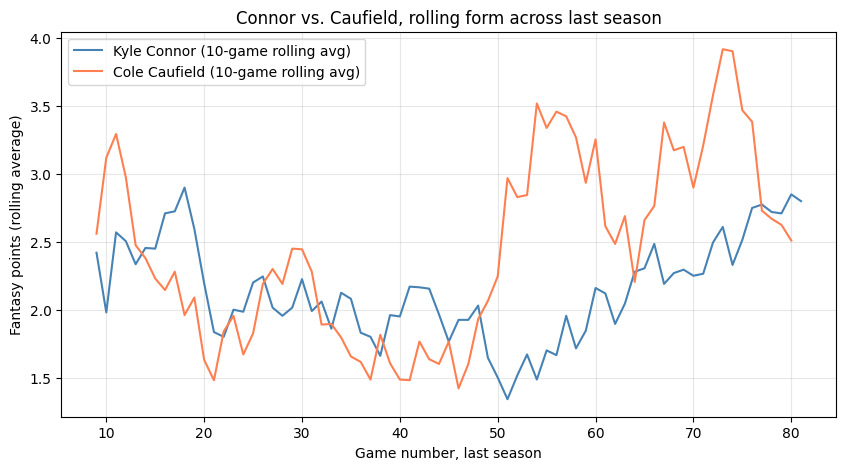

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(connor_log["fantasy_points"].rolling(10).mean(), label="Kyle Connor (10-game rolling avg)", color="steelblue")
plt.plot(caufield_log["fantasy_points"].rolling(10).mean(), label="Cole Caufield (10-game rolling avg)", color="coral")
plt.xlabel("Game number, last season")
plt.ylabel("Fantasy points (rolling average)")
plt.title("Connor vs. Caufield, rolling form across last season")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

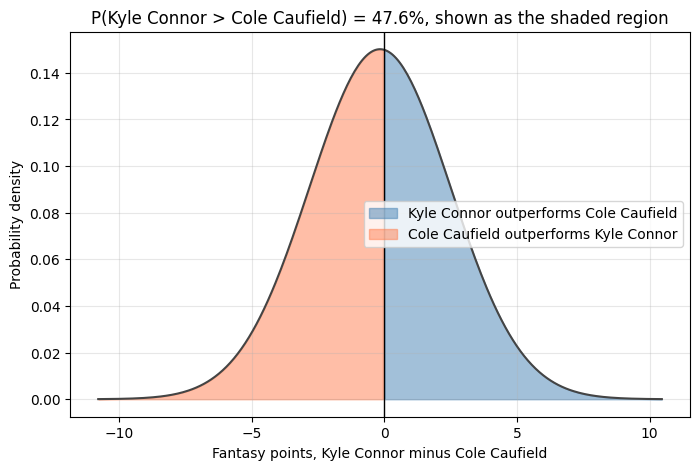

In [17]:
def plot_probability_region(est_a, est_b, label_a, label_b):
    """
    Visualizes P(A > B) directly: computes the distribution of the
    difference D = A - B, and shades the region where D > 0, which is
    exactly the probability compare_players() reports.
    """
    diff_mu = est_a["season_mu"] - est_b["season_mu"]
    diff_sigma = (est_a["season_sigma"]**2 + est_b["season_sigma"]**2) ** 0.5

    x = np.linspace(diff_mu - 4 * diff_sigma, diff_mu + 4 * diff_sigma, 300)
    y = norm.pdf(x, diff_mu, diff_sigma)

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, color="#444444")
    plt.fill_between(x, y, where=(x > 0), color="steelblue", alpha=0.5, label=f"{label_a} outperforms {label_b}")
    plt.fill_between(x, y, where=(x <= 0), color="coral", alpha=0.5, label=f"{label_b} outperforms {label_a}")
    plt.axvline(0, color="black", linewidth=1)

    prob = norm.cdf(diff_mu / diff_sigma) if diff_sigma > 0 else (1.0 if diff_mu > 0 else 0.0)
    plt.title(f"P({label_a} > {label_b}) = {prob:.1%}, shown as the shaded region")
    plt.xlabel(f"Fantasy points, {label_a} minus {label_b}")
    plt.ylabel("Probability density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_probability_region(connor_est, caufield_est, "Kyle Connor", "Cole Caufield")

**Verdict:** The model comes back almost exactly where I guessed,
Caufield favoured, but only slightly (P(Caufield > Connor) ≈ 52.4%).
Given the category breakdown, I feel more confident in the regression
call, not less. Caufield's edge is basically all in goals (1.26 vs
0.95 pts/game from G_pts alone), while Connor actually puts up more
assists and about the same number of shots. Goal totals are the
streakiest stat in hockey, and looking at the rolling average chart,
Caufield's season really does look like a roughly Connor-level pace
for most of the year with one big hot stretch (games ~50-75) doing a
lot of the lifting on his final numbers. Connor, by comparison, was
remarkably even all season.

That lines up with my gut: I think I'm still comfortable making this
trade, the model says it's close either way, and the deeper look
actually reinforces the regression story rather than talking me out
of it. But it's close enough, and Caufield's redraft price (12th vs
20th) high enough, that I wouldn't call this a clearly correct move,
more a bet I'm willing to make.